In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✓ Librerías cargadas")

✓ Librerías cargadas


In [2]:
df = pd.read_csv('../data/processed/cereales_clean.csv')
print(f"Productos cargados: {len(df)}")

cols_nutri = ['Energy', 'Protein', 'Carbohydrate, by difference',
              'Total lipid (fat)', 'Fatty acids, total saturated',
              'Fiber, total dietary', 'Total Sugars', 'Sodium, Na']

X = df[cols_nutri].values
print(f"Matriz de características: {X.shape}")

Productos cargados: 11608
Matriz de características: (11608, 8)


In [3]:
# Aplicar StandardScaler (Z-score: media=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar normalización
print("=== VERIFICACIÓN NORMALIZACIÓN ===")
print(f"Media por variable (debe ser ~0):")
print(np.round(X_scaled.mean(axis=0), 4))
print(f"\nDesv. Est. por variable (debe ser ~1):")
print(np.round(X_scaled.std(axis=0), 4))

# Guardar datos normalizados
df_scaled = pd.DataFrame(X_scaled, columns=cols_nutri)
df_scaled['fdc_id'] = df['fdc_id'].values
df_scaled['description'] = df['description'].values
df_scaled.to_csv('../data/processed/cereales_normalized.csv', index=False)
print("\n✓ Guardado: cereales_normalized.csv")

=== VERIFICACIÓN NORMALIZACIÓN ===
Media por variable (debe ser ~0):
[ 0.  0. -0. -0. -0. -0. -0.  0.]

Desv. Est. por variable (debe ser ~1):
[1. 1. 1. 1. 1. 1. 1. 1.]

✓ Guardado: cereales_normalized.csv


In [4]:
# Aplicar PCA con todos los componentes
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada
var_explicada = pca_full.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

print("=== VARIANZA EXPLICADA POR COMPONENTE ===")
for i, (var, acum) in enumerate(zip(var_explicada, var_acumulada)):
    print(f"PC{i+1}: {var*100:.2f}% (Acumulada: {acum*100:.2f}%)")

=== VARIANZA EXPLICADA POR COMPONENTE ===
PC1: 34.57% (Acumulada: 34.57%)
PC2: 25.52% (Acumulada: 60.09%)
PC3: 13.19% (Acumulada: 73.28%)
PC4: 11.06% (Acumulada: 84.35%)
PC5: 6.84% (Acumulada: 91.19%)
PC6: 5.16% (Acumulada: 96.34%)
PC7: 3.13% (Acumulada: 99.48%)
PC8: 0.52% (Acumulada: 100.00%)


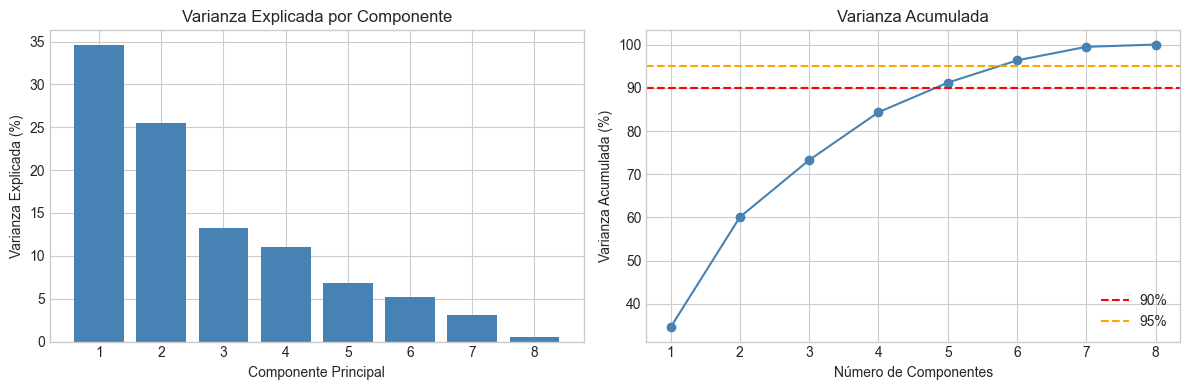

✓ Guardado: pca_varianza.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Varianza por componente
axes[0].bar(range(1, len(var_explicada)+1), var_explicada*100, color='steelblue')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza Explicada por Componente')

# Gráfico 2: Varianza acumulada
axes[1].plot(range(1, len(var_acumulada)+1), var_acumulada*100, 'o-', color='steelblue')
axes[1].axhline(y=90, color='red', linestyle='--', label='90%')
axes[1].axhline(y=95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/pca_varianza.png', dpi=150)
plt.show()
print("✓ Guardado: pca_varianza.png")

In [6]:
# Seleccionar componentes que expliquen >= 90% varianza
n_components = np.argmax(var_acumulada >= 0.90) + 1
print(f"Componentes necesarios para 90% varianza: {n_components}")

# Aplicar PCA con componentes seleccionados
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
print(f"Dimensiones reducidas: {X_scaled.shape} → {X_pca.shape}")

Componentes necesarios para 90% varianza: 5
Dimensiones reducidas: (11608, 8) → (11608, 5)


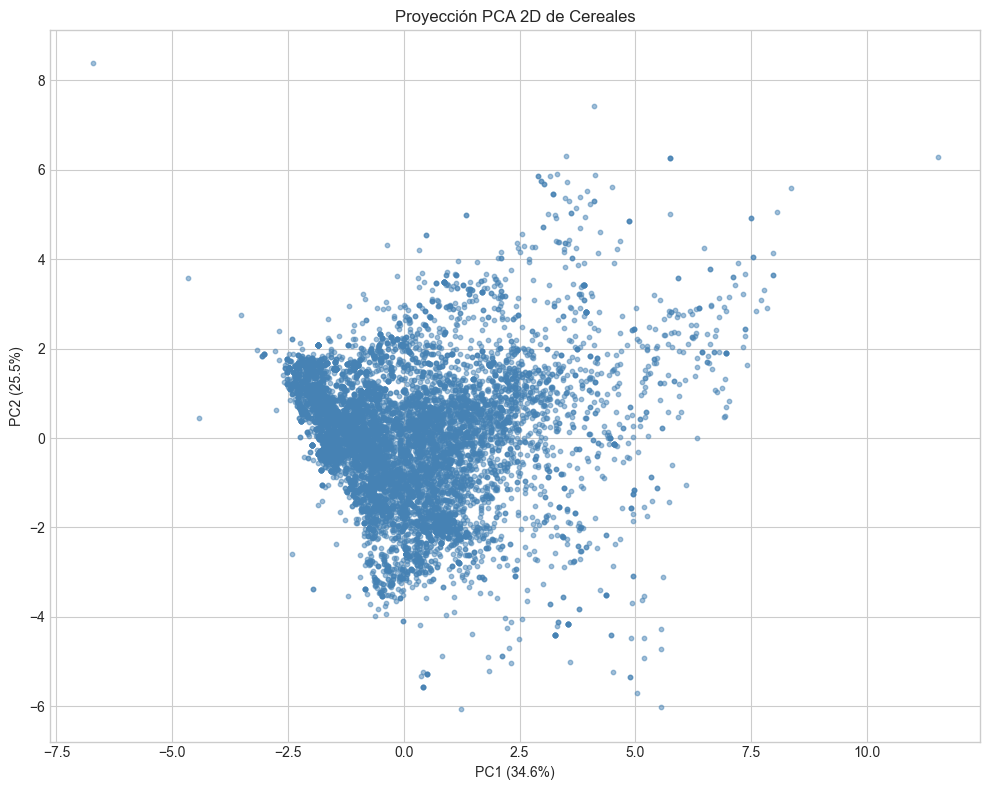

✓ Guardado: pca_2d.png


In [7]:
# PCA con 2 componentes para visualización
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='steelblue')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Proyección PCA 2D de Cereales')
plt.tight_layout()
plt.savefig('../docs/pca_2d.png', dpi=150)
plt.show()
print("✓ Guardado: pca_2d.png")

=== LOADINGS (Contribución de variables) ===
                                PC1    PC2    PC3
Energy                        0.261  0.467  0.494
Protein                       0.346 -0.309  0.321
Carbohydrate, by difference  -0.440  0.181  0.521
Total lipid (fat)             0.516  0.297 -0.033
Fatty acids, total saturated  0.436  0.355 -0.153
Fiber, total dietary          0.211 -0.356  0.571
Total Sugars                 -0.234  0.529  0.018
Sodium, Na                   -0.249  0.181  0.174


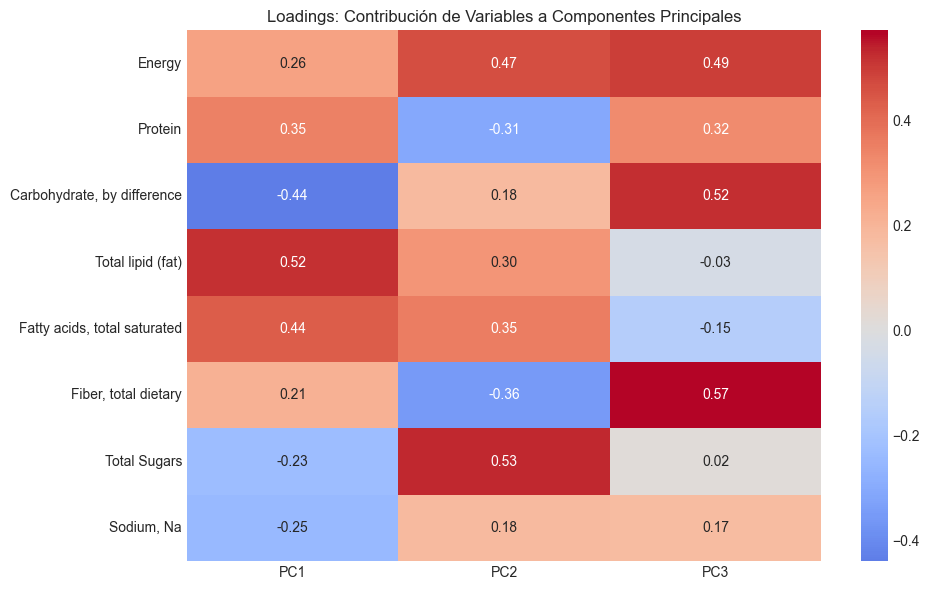

✓ Guardado: pca_loadings.png


In [8]:
# Loadings: cómo contribuye cada variable a cada PC
loadings = pd.DataFrame(
    pca_full.components_.T[:, :3],
    columns=['PC1', 'PC2', 'PC3'],
    index=cols_nutri
)

print("=== LOADINGS (Contribución de variables) ===")
print(loadings.round(3))

# Visualizar loadings
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Loadings: Contribución de Variables a Componentes Principales')
plt.tight_layout()
plt.savefig('../docs/pca_loadings.png', dpi=150)
plt.show()
print("✓ Guardado: pca_loadings.png")

In [9]:
# Crear dataframe con representación PCA
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
df_pca['fdc_id'] = df['fdc_id'].values
df_pca['description'] = df['description'].values

df_pca.to_csv('../data/processed/cereales_pca.csv', index=False)
print(f"✓ Guardado: cereales_pca.csv ({n_components} componentes)")

✓ Guardado: cereales_pca.csv (5 componentes)


In [10]:
print("=" * 50)
print("RESUMEN FASE 2: REPRESENTACIONES")
print("=" * 50)
print(f"\n1. DATOS ORIGINALES")
print(f"   - Productos: {len(df)}")
print(f"   - Variables: {len(cols_nutri)}")

print(f"\n2. NORMALIZACIÓN Z-SCORE")
print(f"   - Archivo: cereales_normalized.csv")
print(f"   - Dimensiones: {X_scaled.shape}")

print(f"\n3. PCA")
print(f"   - Componentes para 90% varianza: {n_components}")
print(f"   - Archivo: cereales_pca.csv")
print(f"   - Dimensiones: {X_pca.shape}")


RESUMEN FASE 2: REPRESENTACIONES

1. DATOS ORIGINALES
   - Productos: 11608
   - Variables: 8

2. NORMALIZACIÓN Z-SCORE
   - Archivo: cereales_normalized.csv
   - Dimensiones: (11608, 8)

3. PCA
   - Componentes para 90% varianza: 5
   - Archivo: cereales_pca.csv
   - Dimensiones: (11608, 5)


In [11]:
# AUTOENCODER

In [12]:
# Autoencoder con TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [13]:
# Arquitectura del autoencoder
# 8 variables → 5 → 3 (latente) → 5 → 8

input_dim = X_scaled.shape[1]  # 8 variables
latent_dim = 3  # Dimensión del espacio latente

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(5, activation='relu')(input_layer)
latent = Dense(latent_dim, activation='relu', name='latent')(encoded)

# Decoder
decoded = Dense(5, activation='relu')(latent)
output_layer = Dense(input_dim, activation='linear')(decoded)

# Modelo completo
autoencoder = Model(input_layer, output_layer)

# Modelo encoder (para extraer representación)
encoder = Model(input_layer, latent)

# Compilar
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Resumen
print("=== ARQUITECTURA DEL AUTOENCODER ===")
autoencoder.summary()

=== ARQUITECTURA DEL AUTOENCODER ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Early stopping para evitar sobreajuste
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrenar
print("\nEntrenando autoencoder...")
history = autoencoder.fit(
    X_scaled, X_scaled,  # Input = Output (reconstrucción)
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✓ Entrenamiento completado en {len(history.history['loss'])} épocas")
print(f"Loss final: {history.history['loss'][-1]:.4f}")
print(f"Val Loss final: {history.history['val_loss'][-1]:.4f}")


Entrenando autoencoder...
Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 473us/step - loss: 0.7570 - val_loss: 0.8589
Epoch 2/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - loss: 0.4788 - val_loss: 0.5597
Epoch 3/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step - loss: 0.3795 - val_loss: 0.4738
Epoch 4/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step - loss: 0.3371 - val_loss: 0.4221
Epoch 5/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step - loss: 0.3105 - val_loss: 0.4001
Epoch 6/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step - loss: 0.2949 - val_loss: 0.3727
Epoch 7/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step - loss: 0.2853 - val_loss: 0.3584
Epoch 8/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step - loss: 0.2791 - val_loss: 0.3596
Epoch 9/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step - loss: 0.2746 - val_loss: 0.3389
Epoch 10/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step - loss: 0.2716 - val_loss: 0.3390
Epoch 11/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 277us/step - loss: 0.2696 - val_loss:

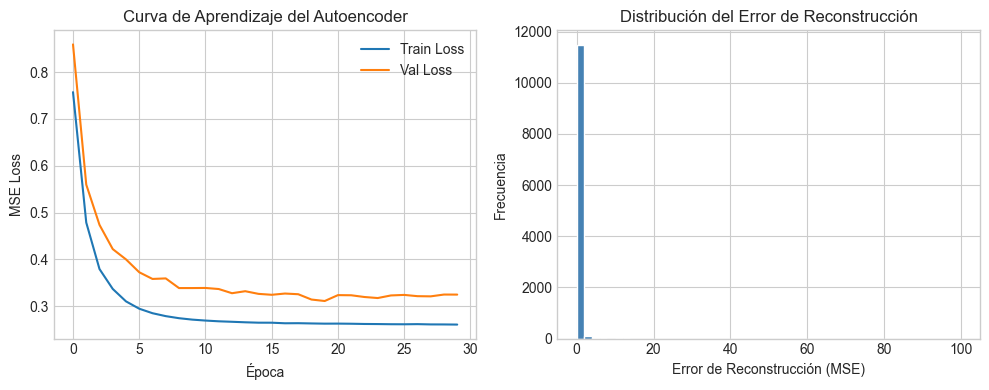

✓ Guardado: autoencoder_training.png


In [15]:
# Curva de pérdida
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Curva de Aprendizaje del Autoencoder')
plt.legend()

# Error de reconstrucción por muestra
X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
reconstruction_error = np.mean((X_scaled - X_reconstructed)**2, axis=1)

plt.subplot(1, 2, 2)
plt.hist(reconstruction_error, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Error de Reconstrucción (MSE)')
plt.ylabel('Frecuencia')
plt.title('Distribución del Error de Reconstrucción')

plt.tight_layout()
plt.savefig('../docs/autoencoder_training.png', dpi=150)
plt.show()
print("✓ Guardado: autoencoder_training.png")

In [16]:
# Obtener representación latente
X_autoencoder = encoder.predict(X_scaled, verbose=0)
print(f"Representación autoencoder: {X_autoencoder.shape}")

# Guardar
df_ae = pd.DataFrame(X_autoencoder, columns=[f'AE{i+1}' for i in range(latent_dim)])
df_ae['fdc_id'] = df['fdc_id'].values
df_ae['description'] = df['description'].values
df_ae.to_csv('../data/processed/cereales_autoencoder.csv', index=False)
print("✓ Guardado: cereales_autoencoder.csv")

Representación autoencoder: (11608, 3)
✓ Guardado: cereales_autoencoder.csv


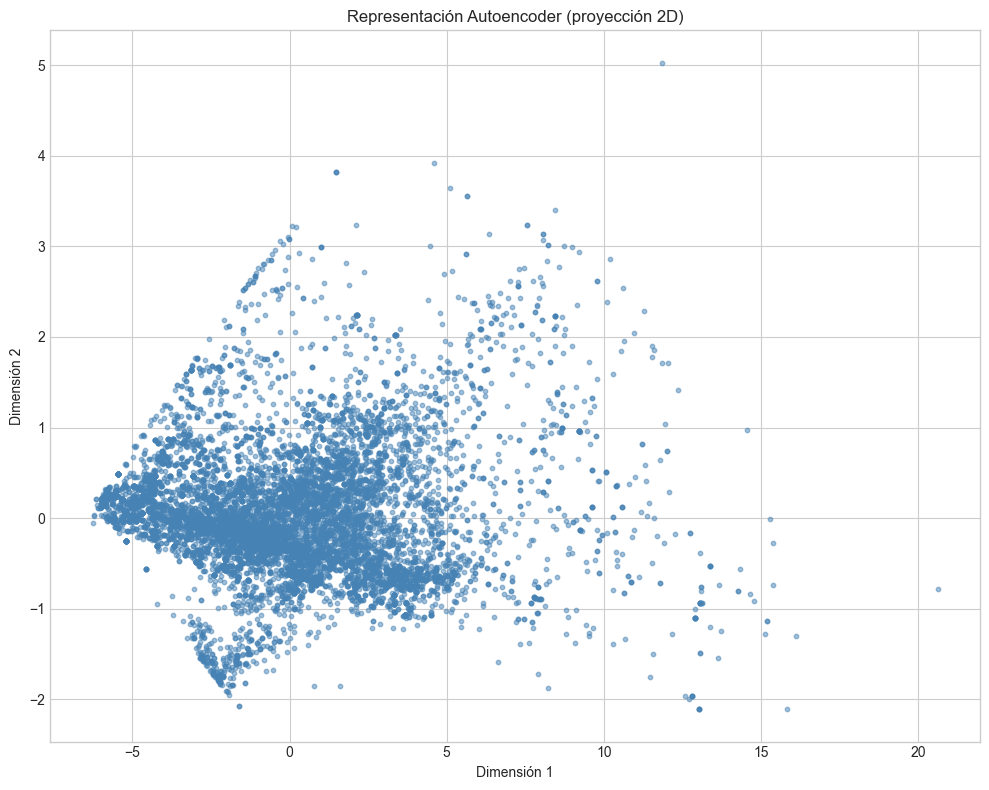

✓ Guardado: autoencoder_2d.png


In [17]:
# Si latent_dim > 2, usar PCA para visualizar
if latent_dim > 2:
    pca_ae = PCA(n_components=2)
    X_ae_2d = pca_ae.fit_transform(X_autoencoder)
else:
    X_ae_2d = X_autoencoder[:, :2]

plt.figure(figsize=(10, 8))
plt.scatter(X_ae_2d[:, 0], X_ae_2d[:, 1], alpha=0.5, s=10, c='steelblue')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.title('Representación Autoencoder (proyección 2D)')
plt.tight_layout()
plt.savefig('../docs/autoencoder_2d.png', dpi=150)
plt.show()
print("✓ Guardado: autoencoder_2d.png")

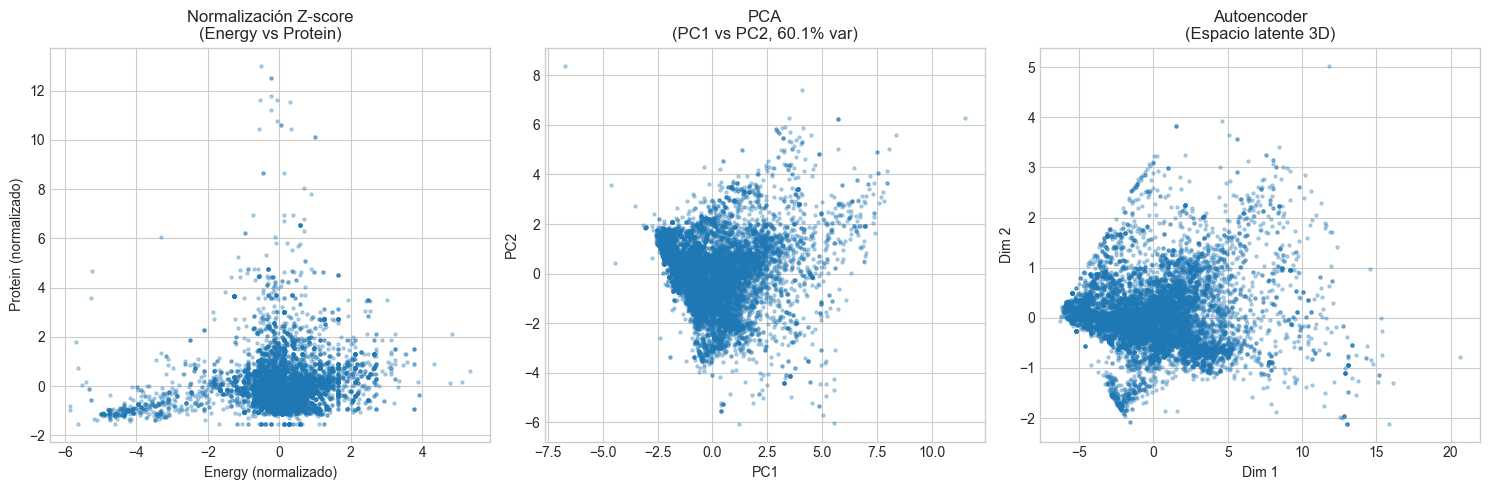

✓ Guardado: comparacion_representaciones.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Datos normalizados (primeras 2 variables)
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.3, s=5)
axes[0].set_title('Normalización Z-score\n(Energy vs Protein)')
axes[0].set_xlabel('Energy (normalizado)')
axes[0].set_ylabel('Protein (normalizado)')

# 2. PCA
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=5)
axes[1].set_title(f'PCA\n(PC1 vs PC2, {(pca_2d.explained_variance_ratio_.sum()*100):.1f}% var)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# 3. Autoencoder
axes[2].scatter(X_ae_2d[:, 0], X_ae_2d[:, 1], alpha=0.3, s=5)
axes[2].set_title(f'Autoencoder\n(Espacio latente {latent_dim}D)')
axes[2].set_xlabel('Dim 1')
axes[2].set_ylabel('Dim 2')

plt.tight_layout()
plt.savefig('../docs/comparacion_representaciones.png', dpi=150)
plt.show()
print("✓ Guardado: comparacion_representaciones.png")

In [19]:
# Guardar el scaler y encoder para uso posterior
import joblib

joblib.dump(scaler, '../src/scaler.pkl')
encoder.save('../src/encoder_model.keras')

print("✓ Guardado: scaler.pkl")
print("✓ Guardado: encoder_model.keras")

✓ Guardado: scaler.pkl
✓ Guardado: encoder_model.keras


In [20]:
print("=" * 60)
print("RESUMEN FASE 2: APRENDIZAJE DE REPRESENTACIONES")
print("=" * 60)

print(f"\n1. NORMALIZACIÓN Z-SCORE")
print(f"   Archivo: cereales_normalized.csv")
print(f"   Dimensiones: {X_scaled.shape}")

print(f"\n2. PCA")
print(f"   Archivo: cereales_pca.csv")
print(f"   Componentes: {n_components} (para 90% varianza)")
print(f"   Dimensiones: {X_pca.shape}")

print(f"\n3. AUTOENCODER")
print(f"   Archivo: cereales_autoencoder.csv")
print(f"   Arquitectura: 8 → 5 → {latent_dim} → 5 → 8")
print(f"   Loss final: {history.history['loss'][-1]:.4f}")
print(f"   Dimensiones: {X_autoencoder.shape}")

print(f"\n" + "=" * 60)
print("ARCHIVOS GENERADOS:")
print("=" * 60)
print("  data/processed/cereales_normalized.csv")
print("  data/processed/cereales_pca.csv")
print("  data/processed/cereales_autoencoder.csv")
print("  docs/pca_varianza.png")
print("  docs/pca_2d.png")
print("  docs/pca_loadings.png")
print("  docs/autoencoder_training.png")
print("  docs/autoencoder_2d.png")
print("  docs/comparacion_representaciones.png")
print("  src/scaler.pkl")
print("  src/encoder_model.keras")

print(f"\n✓ Fase 2 completada")
print("Continuar con: 04_clustering.ipynb")

RESUMEN FASE 2: APRENDIZAJE DE REPRESENTACIONES

1. NORMALIZACIÓN Z-SCORE
   Archivo: cereales_normalized.csv
   Dimensiones: (11608, 8)

2. PCA
   Archivo: cereales_pca.csv
   Componentes: 5 (para 90% varianza)
   Dimensiones: (11608, 5)

3. AUTOENCODER
   Archivo: cereales_autoencoder.csv
   Arquitectura: 8 → 5 → 3 → 5 → 8
   Loss final: 0.2610
   Dimensiones: (11608, 3)

ARCHIVOS GENERADOS:
  data/processed/cereales_normalized.csv
  data/processed/cereales_pca.csv
  data/processed/cereales_autoencoder.csv
  docs/pca_varianza.png
  docs/pca_2d.png
  docs/pca_loadings.png
  docs/autoencoder_training.png
  docs/autoencoder_2d.png
  docs/comparacion_representaciones.png
  src/scaler.pkl
  src/encoder_model.keras

✓ Fase 2 completada
Continuar con: 04_clustering.ipynb


In [21]:
## 5. Análisis de Tendencia al Agrupamiento (Estadístico de Hopkins)

In [22]:
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, sample_size=None, random_state=42):
    """
    Calcula el estadístico de Hopkins para evaluar la tendencia
    al agrupamiento (cluster tendency) de un dataset.
    
    H ≈ 0.5 → datos aleatorios (sin estructura)
    H → 1.0 → datos con estructura de clusters bien definida
    H → 0.0 → datos distribuidos uniformemente en cuadrícula
    
    Args:
        X: array numpy normalizado (n_samples, n_features)
        sample_size: número de puntos a muestrear (default: 10% de n)
        random_state: semilla aleatoria para reproducibilidad
    
    Returns:
        float: valor del estadístico de Hopkins [0, 1]
    """
    np.random.seed(random_state)
    n, d = X.shape
    
    if sample_size is None:
        sample_size = max(int(0.10 * n), 50)
    
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    
    idx = np.random.choice(n, sample_size, replace=False)
    X_sample = X[idx]
    
    X_random = np.random.uniform(low=X_min, high=X_max, size=(sample_size, d))
    
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    
    u_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)
    u = u_dist[:, 1]
    
    w_dist, _ = nbrs.kneighbors(X_random, n_neighbors=1)
    w = w_dist[:, 0]
    
    H = w.sum() / (u.sum() + w.sum())
    return H


# --- Cálculo sobre las tres representaciones ---

print("=" * 55)
print("ESTADÍSTICO DE HOPKINS - Tendencia al agrupamiento")
print("=" * 55)

H_norm = hopkins_statistic(X_scaled, random_state=42)
print(f"\n📊 Datos normalizados (8D):       H = {H_norm:.4f}")

H_pca = hopkins_statistic(X_pca, random_state=42)
print(f"📊 Representación PCA (5D):       H = {H_pca:.4f}")

H_ae = hopkins_statistic(X_autoencoder, random_state=42)
print(f"📊 Representación Autoencoder (3D): H = {H_ae:.4f}")

print("\n--- Interpretación ---")
for nombre, H in [("Normalizado", H_norm), ("PCA", H_pca), ("Autoencoder", H_ae)]:
    if H >= 0.75:
        nivel = "✅ Alta tendencia al clustering (estructura muy clara)"
    elif H >= 0.5:
        nivel = "⚠️  Tendencia moderada al clustering"
    else:
        nivel = "❌ Baja tendencia (datos casi aleatorios)"
    print(f"  {nombre}: H={H:.4f} → {nivel}")

ESTADÍSTICO DE HOPKINS - Tendencia al agrupamiento

📊 Datos normalizados (8D):       H = 0.9850
📊 Representación PCA (5D):       H = 0.9861
📊 Representación Autoencoder (3D): H = 0.9886

--- Interpretación ---
  Normalizado: H=0.9850 → ✅ Alta tendencia al clustering (estructura muy clara)
  PCA: H=0.9861 → ✅ Alta tendencia al clustering (estructura muy clara)
  Autoencoder: H=0.9886 → ✅ Alta tendencia al clustering (estructura muy clara)
